In [8]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

BASE_DIR = os.path.join("results", "amazon")

def parse_benchmark_times(base_dir):
    records = []
    for d in sorted(os.listdir(base_dir)):
        full_path = os.path.join(base_dir, d)
        if not os.path.isdir(full_path) or not d.startswith("LPA_"):
            continue
        
        parts = d.split("_")
        is_gf = parts[1] == "GF"
        algo = "GraphFrames" if is_gf else "Ours (RDD)"
        cores = int(parts[2].replace("local", ""))
        
        time_file = os.path.join(full_path, "gf_benchmark_times.txt" if is_gf else "benchmark_times.txt")
        if os.path.exists(time_file):
            with open(time_file) as f:
                line = f.readline().strip()
                if line:
                    t = float(line.split(",")[1])
                    records.append({"algo": algo, "cores": cores, "time": t, "dir_name": d})
                    
    return pd.DataFrame(records).sort_values(by=["algo", "cores"])

def read_spark_csv(dir_path):
    # Reads partitioned CSVs and enforces disjoint sets for standard metrics
    files = glob.glob(os.path.join(dir_path, "part-[0-9]*"))
    if not files:
        return pd.DataFrame(columns=["node", "comm"])
    df = pd.concat([pd.read_csv(f, header=None, names=["node", "comm"]) for f in files])
    return df.drop_duplicates(subset=["node"]).sort_values("node")

def read_full_ground_truth(gt_dir):
    # Preserves overlapping memberships for SNAP benchmark metrics
    files = glob.glob(os.path.join(gt_dir, "part-[0-9]*"))
    if not files:
        return pd.DataFrame(columns=["node", "comm"])
    return pd.concat([pd.read_csv(f, header=None, names=["node", "comm"]) for f in files])

def compute_avg_f1(df_res, df_gt_all):
    if df_gt_all.empty or df_res.empty:
        return 0.0

    gt_clusters = df_gt_all.groupby("comm")["node"].apply(set).to_dict()
    pred_map = dict(zip(df_res["node"], df_res["comm"]))
    pred_sizes = df_res["comm"].value_counts().to_dict()

    f1_scores = []
    for _, gt_nodes in gt_clusters.items():
        if not gt_nodes:
            continue

        candidate_counts = Counter(pred_map[u] for u in gt_nodes if u in pred_map)
        if not candidate_counts:
            f1_scores.append(0.0)
            continue

        len_gt = len(gt_nodes)
        best_f1 = max(
            (2.0 * intersection) / (len_gt + pred_sizes[c])
            for c, intersection in candidate_counts.items()
        )
        f1_scores.append(best_f1)

    return sum(f1_scores) / len(f1_scores) if f1_scores else 0.0

=== EXECUTION TIME (seconds) ===
       algo  cores      time
GraphFrames      4   37.0511
GraphFrames      8   32.3527
GraphFrames     16   30.7028
GraphFrames     20   32.3405
       Ours      4 1538.1270
       Ours      8  774.7176
       Ours     16  384.6318
       Ours     20  338.1926


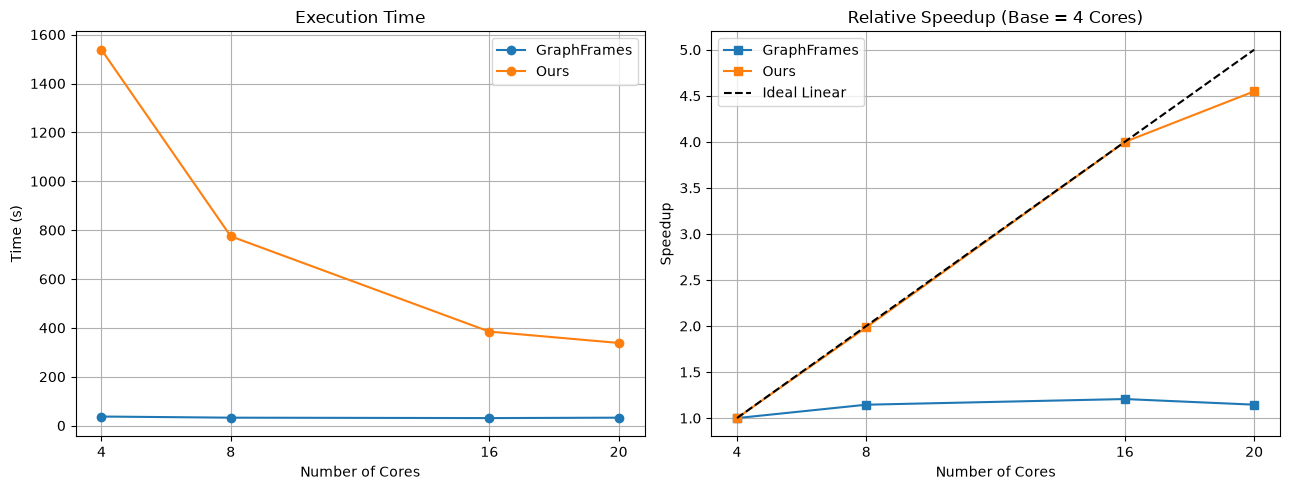

In [9]:
df_bench = parse_benchmark_times(BASE_DIR)
name_mapping = {"Ours (RDD)":"Ours"}
df_bench["algo"] = df_bench["algo"].replace(name_mapping)

print("=== EXECUTION TIME (seconds) ===")
print(df_bench[["algo", "cores", "time"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for algo, group in df_bench.groupby("algo"):
    axes[0].plot(group["cores"], group["time"], marker="o", label=algo)
    base_time = group[group["cores"] == 4]["time"].values[0]
    speedup = base_time / group["time"]
    axes[1].plot(group["cores"], speedup, marker="s", label=algo)

axes[0].set_title("Execution Time")
axes[0].set_xlabel("Number of Cores")
axes[0].set_ylabel("Time (s)")
axes[0].set_xticks([4, 8, 16, 20])
axes[0].grid(True)
axes[0].legend()

# Ideal linear speedup normalized to 4 cores base
ideal_cores = [4, 8, 16, 20]
ideal_speedup = [c / 4 for c in ideal_cores]
axes[1].plot(ideal_cores, ideal_speedup, "k--", label="Ideal Linear")

axes[1].set_title("Relative Speedup (Base = 4 Cores)")
axes[1].set_xlabel("Number of Cores")
axes[1].set_ylabel("Speedup")
axes[1].set_xticks(ideal_cores)
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
fig.savefig("amazon_time_results.pdf", bbox_inches="tight")
plt.show()

In [10]:
qual_records = []
cached_dfs = {}
evaluated = set()

# Load GT once (using 4-core directory as representative)
sample_dir = df_bench[df_bench["algo"] == "Ours"].iloc[0]["dir_name"]
gt_path = os.path.join(BASE_DIR, sample_dir, "gt_mapped")
df_gt_all = read_full_ground_truth(gt_path)
df_gt_disjoint = df_gt_all.drop_duplicates(subset=["node"]).sort_values("node")
cached_dfs["gt_all"] = df_gt_all

for _, row in df_bench.iterrows():
    algo = row["algo"]
    if algo in evaluated:
        continue

    d_path = os.path.join(BASE_DIR, row["dir_name"])
    is_gf = "GF" in row["dir_name"]
    res_dir = os.path.join(d_path, "results_lpa_gf" if is_gf else "results_lpa")

    df_res = read_spark_csv(res_dir)
    cached_dfs[algo] = df_res

    # 1. Overlapping SNAP Metric
    avg_f1 = compute_avg_f1(df_res, df_gt_all)

    # 2. Standard Disjoint Metrics
    merged = pd.merge(df_res, df_gt_disjoint, on="node", suffixes=("_pred", "_gt"))
    nmi = normalized_mutual_info_score(merged["comm_gt"], merged["comm_pred"])
    ari = adjusted_rand_score(merged["comm_gt"], merged["comm_pred"])

    # 3. Community Distribution Stats
    comm_counts = df_res["comm"].value_counts()
    num_comms = len(comm_counts)
    max_comm_size = comm_counts.iloc[0]
    median_comm_size = comm_counts.median()
    singletons_pct = (comm_counts == 1).mean() * 100 if not comm_counts.empty else 0.0
    qual_records.append({
        "Algorithm": algo,
        "Avg F1": round(avg_f1, 4),
        "NMI": round(nmi, 4),
        "ARI": round(ari, 4),
        "Num Comms": num_comms,
        "Median Size": int(median_comm_size),
        "Max Size": max_comm_size,
        "Singletons (%)": round(singletons_pct, 2),
        "Evaluated Nodes (GT)": len(merged)
    })
    evaluated.add(algo)

df_qual = pd.DataFrame(qual_records)
print("=== CLUSTERING QUALITY ===")
print(df_qual.to_string(index=False))

=== CLUSTERING QUALITY ===
  Algorithm  Avg F1    NMI    ARI  Num Comms  Median Size  Max Size  Singletons (%)  Evaluated Nodes (GT)
GraphFrames  0.8555 0.9521 0.5850      27049            7       627            5.83                 16716
       Ours  0.9033 0.9535 0.5712      35446            6       440            1.60                 16716


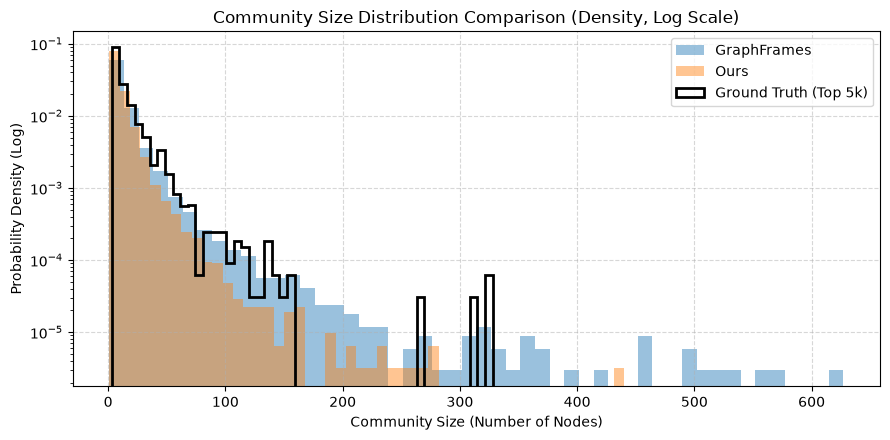

In [12]:
sizes_gf = cached_dfs["GraphFrames"]["comm"].value_counts()
sizes_ours = cached_dfs["Ours"]["comm"].value_counts()
sizes_gt = cached_dfs["gt_all"].groupby("comm").size()

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.hist(sizes_gf, bins=50, density=True, log=True, alpha=0.45, label="GraphFrames")
ax.hist(sizes_ours, bins=50, density=True, log=True, alpha=0.45, label="Ours")
ax.hist(sizes_gt, bins=50, density=True, log=True, histtype="step", linewidth=2, color="black", label="Ground Truth (Top 5k)")

ax.set_title("Community Size Distribution Comparison (Density, Log Scale)")
ax.set_xlabel("Community Size (Number of Nodes)")
ax.set_ylabel("Probability Density (Log)")
ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
fig.savefig("amazon_distribuition_results.pdf", bbox_inches="tight")
plt.show()